# Distribution Transformations

---

### What is Skewness?

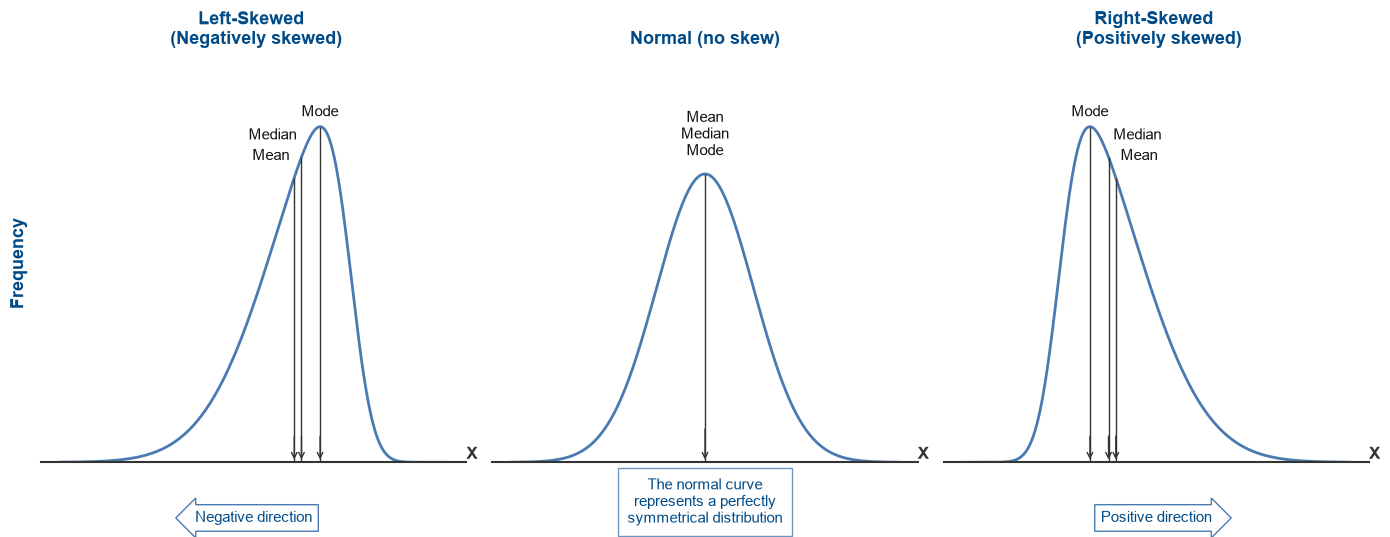

**Skewness** is a statistical measure that quantifies the asymmetry of a data distribution around its mean. In a perfectly symmetrical distribution (like a standard normal bell curve), the skewness score is exactly **0**, and the mean, median, and mode are all equal.

When data points clump up heavily on one side and leave a long trailing tail on the other side, the distribution is skewed:

* **Right (Positive) Skewness:** The distribution tail stretches far out to the **right**. Most values are packed on the lower/left side.
* **Left (Negative) Skewness:** The distribution tail stretches far out to the **left**. Most values are packed on the higher/right side.

---

### How Skewness Affects Linear Regression

Linear regression does not strictly require the input features (\(X\)) or target variable (\(y\)) to be perfectly normal to generate a baseline mathematical line. However, severe skewness violates key statistical underpinnings and introduces several structural issues into your model:

#### 1. Over-leveraging Extreme Outliers (Distorted Best-Fit Line)
Linear regression relies on **Ordinary Least Squares (OLS)**, which fits a line by minimizing the *squared* distance between the line and the data points (\(Error^2\)). 
* When a feature is highly right-skewed, a few exceptionally large values sit far out on the right tail. 
* Squaring these large distances creates massive penalties. The regression line will aggressively tilt itself away from the majority of your data points just to get closer to those few extreme values.

#### 2. Violation of Equality of Variances (Homoscedasticity)
Linear regression assumes **homoscedasticity**, meaning the variance of your model's prediction errors (residuals) must remain constant across all levels of your predictor variables.
* Highly skewed features almost always introduce **heteroscedasticity** (non-constant variance).
* As values grow larger along the stretched-out tail, the spread of data points typically expands. Your model will become highly accurate for small values but wildly unpredictable and unstable for larger values.

#### 3. Violation of Normality of Residuals
For the confidence intervals, p-values, and significance tests of a linear regression model to be statistically valid, the model's *errors (residuals)* must be normally distributed.
* If your dependent variable (\(y\)) is severely skewed, the errors generated by a linear model will inherit that skewness. 
* This means you cannot trust the p-values or confidence intervals your model outputs to determine if a variable is actually an important predictor.

#### 4. Uneven Data Subspaces
When features are highly skewed, the model is forced to make predictions across a sparse data landscape. It has thousands of data points packed closely together at one end, but almost no information along the vast stretch of the tail. This causes the model to generalize poorly on new, incoming test data.

---




### Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 


## Distribution Transformations: Why?
Many machine learning models perform poorly when features are highly skewed (e.g., Income, Population, Call Durations). 

* **Non-Normal Distributions:** Linear models and parametric tests assume that residuals are normally distributed. Highly skewed data violates this assumption, distorting confidence intervals and model predictions.
* **Sensitivity to Outliers:** Extreme values pull the mean and variance, causing models to prioritize fitting anomalies rather than the underlying trends.

### 2. The Solution
Transformations apply deterministic mathematical operations to every data point within a feature. 
* They alter the geometry of the feature space to stabilize variance and reshape probability density functions into symmetrical distributions.

---

## Popular Distribution Tranformers:

### 1. Log Transformation
Replaces each value with its natural or base-10 logarithm ($X \rightarrow \ln(X)$).
* **When to use:** Right-skewed (positive) distributions spanning multiple orders of magnitude.
* **Limitation:** Undefined for zero or negative values. To handle zero, data scientists apply the $log(x + 1)$ transformation (implemented via `np.log1p`).

### 2. Power Transformations
Parametric transformations that use a stabilizer parameter ($\lambda$) to systematically shift data toward a normal distribution.
* **Box-Cox:** Extremely effective but strictly requires all input values to be **strictly positive** ($X > 0$).
* **Yeo-Johnson:** A modern modification of Box-Cox that allows for **zero and negative values**.

### 3. Quantile Transformations (Avoid using with Linear Regression)
Maps the original feature distribution to a target distribution (typically a uniform or normal distribution) using non-parametric rank transformation.
* **When to use:** Highly non-linear, bimodal, or multi-modal distributions that parametric transformations fail to smooth out.
* **Limitation:** Distorts the absolute linear distances between close values; breaks down standard correlation metrics.

---


### Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |
| **Quantile Transformer** | Multi-modal, heavily skewed, or extreme outliers |  Yes |  Yes | Forces any distribution pattern into a smooth, normal shape. **Warning:** Not to be used with Linear Regression. It distorts relative variable distance. |



### Finding Skewness Using `Pandas` or `scipy`

#### a. in Pandas, using the `.skew()` method

```python
skew_value = df['column'].skew()
```
#### b. using scipy.stats `skew()` function
```python
from scipy.stats import skew
skew_value= skew(df['column'], bias=False)
```

* **important note**: skewness should be checked for `continuous numeric variables` only.
* **Should not checked for**:
  - Identifications and Timestamps: primary keys, user IDs, zip codes, phone numbers,..etc
  - Binary / Dummy Variables
  - One-Hot Encoded Columns
  - Ordinal Variables



In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import skew



### Generate random dataframe with different skewness
- Run below cell to generate a synthetic, messy dataset containing different scales, heavy right skewness, and extreme outliers.

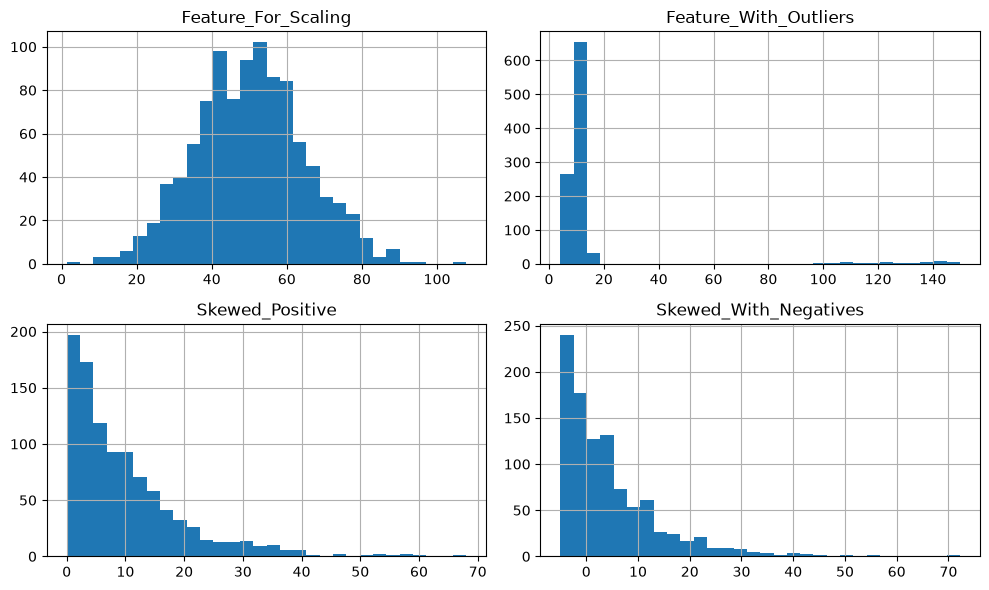

In [19]:
# Generate reproducible synthetic data
np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    'Feature_For_Scaling': np.random.normal(loc=50, scale=15, size=n_samples),
    'Feature_With_Outliers': np.append(np.random.normal(loc=10, scale=2, size=950), np.random.uniform(low=100, high=150, size=50)),
    'Skewed_Positive': np.random.exponential(scale=10, size=n_samples),
    'Skewed_With_Negatives_values': np.random.exponential(scale=10, size=n_samples) - 5
})

# Quick check on the raw distributions
df.hist(figsize=(10, 6), bins=30)
plt.tight_layout()
plt.show()

In [1]:
# Calculate skewness for all numerical features


# Filter and display columns with severe skewness (typically > 1 or < -1)



## Applying Distribution Transformations

### 1. Log Transformation
Flattens right-skewed data. We use `np.log1p(x)` to automatically calculate \(log(x + 1)\) safely.

In [2]:
# Safe log transformation for features that could contain zero


# Compare skewness before and after (closer to 0 is better)



### Before vs After `log`


In [5]:
# 1. Setup layout (increased figsize slightly for better vertical breathing room)


# Define clean, professional colors
color_before = '#d95f02'  # Muted crimson/orange for original skewed data
color_after = '#1b9e77'   # Clean teal/green for transformed distributions

# 2. Top Row: Positive Skew & Log Transformation




# 4. Global Styling Adjustments
# for ax in axes.flatten():
#     ax.grid(True, linestyle='--', alpha=0.5, zorder=0)  # Light grid behind bars
#     ax.set_axisbelow(True)                             # Keep grid lines behind data
#     ax.spines['top'].set_visible(False)                # Remove top border
#     ax.spines['right'].set_visible(False)              # Remove right border
#     ax.tick_params(labelsize=10)                       # Clean tick labels
#     ax.set_ylabel('Frequency', fontsize=10)            # Add proper Y-axis context

# # 5. Fix layout overlap bug and render
# plt.tight_layout()  
# plt.show()

### 2. Power Transformations (Box-Cox & Yeo-Johnson)
Parametric shifts toward normality. Box-Cox strictly requires values > 0. Yeo-Johnson handles zero and negative numbers.


In [6]:
# from sklearn.preprocessing import PowerTransformer

# 1. Box-Cox (Requires strictly positive inputs)



# 2. Yeo-Johnson (Accepts negative values)






### Before vs After `Box_Cox` and `Yeo_Johnson`

In [7]:
# 1. Setup layout (increased figsize slightly for better vertical breathing room)


# # Define clean, professional colors
# color_before = '#d95f02'  # Muted crimson/orange for original skewed data
# color_after = '#1b9e77'   # Clean teal/green for transformed distributions

# # 2. Top Row: Positive Skew & Box-Cox Transformation



# # 3. Bottom Row: Negative Skew & Yeo-Johnson Transformation




# # 4. Global Styling Adjustments
# for ax in axes.flatten():
#     ax.grid(True, linestyle='--', alpha=0.5, zorder=0)  # Light grid behind bars
#     ax.set_axisbelow(True)                             # Keep grid lines behind data
#     ax.spines['top'].set_visible(False)                # Remove top border
#     ax.spines['right'].set_visible(False)              # Remove right border
#     ax.tick_params(labelsize=10)                       # Clean tick labels
#     ax.set_ylabel('Frequency', fontsize=10)            # Add proper Y-axis context

# # 5. Fix layout overlap bug and render
# plt.tight_layout()  
# plt.show()




### 3. Quantile Transformations
- **`Avoid` using it with Linear Regression as it breaks linearity**
- Forcing highly non-linear features into a perfect target probability distribution (e.g., standard normal).

In [9]:
# from sklearn.preprocessing import QuantileTransformer

# Quantile transformer mapping to a normal distribution
# qt = QuantileTransformer(output_distribution='normal', random_state=42)
# df['Quantile_Normal'] = qt.fit_transform(df[['Skewed_Positive']])

# print(f"Quantile Normal Skew: {df['Quantile_Normal'].skew():.4f} (Expect ~0)")

### Before vs After `Quantile`
Run this diagnostic block to visually confirm how your transformations altered the feature space geometry.

In [8]:
# 1. Setup layout (increased figsize slightly for better vertical breathing room)


# Define clean, professional colors
color_before = '#d95f02'  # Muted crimson/orange for original skewed data
color_after = '#1b9e77'   # Clean teal/green for transformed distributions

# 2. Top Row: Positive Skew & Quantile Transformation


# 4. Global Styling Adjustments
# for ax in axes.flatten():
#     ax.grid(True, linestyle='--', alpha=0.5, zorder=0)  # Light grid behind bars
#     ax.set_axisbelow(True)                             # Keep grid lines behind data
#     ax.spines['top'].set_visible(False)                # Remove top border
#     ax.spines['right'].set_visible(False)              # Remove right border
#     ax.tick_params(labelsize=10)                       # Clean tick labels
#     ax.set_ylabel('Frequency', fontsize=10)            # Add proper Y-axis context

# # 5. Fix layout overlap bug and render
# plt.tight_layout()  
# plt.show()